In [13]:
import numpy as _np
from time import time as _time
from copy import deepcopy as _dcopy
from matplotlib import pyplot as plt

import pyaccel as _pyacc
from pymodels import si as _si
from apsuite.optics_analysis.tune_correction import TuneCorr as _TuneCorr

from mathphys.functions import save, load
from siriuspy.opticscorr.csdev import Const as _Const
from siriuspy.opticscorr.opticscorr import OpticsCorr as _OpticsCorr
from siriuspy.opticscorr.utils import HandleConfigNameFile \
    as _HandleConfigNameFile

from siriuspy.clientconfigdb import ConfigDBClient as _ConfigDBClient, \
    ConfigDBException as _ConfigDBException

TWOPI = _np.pi * 2

In [14]:
# auxiliar

AT_HOME = False


class Aux:
    """."""
    def __init__(self):
        """."""
        self._acc = 'SI'
        self._optics_param = 'tune'

        self._psfams = _Const.SI_QFAMS_TUNECORR
        self._psfam_nelm = _Const.SI_QFAMS_NELM
        self._corr_method = _Const.CorrMeth.Proportional
        self._corr_group = _Const.CorrGroup.TwoKnobs

        if not AT_HOME:
            print('Loading data from DBClient')
            self.cn_handler = _HandleConfigNameFile(
                self._acc, self._optics_param)
            self.cdb_client = _ConfigDBClient(
            config_type=self._acc.lower()+'_'+self._optics_param+'corr_params')
            [done, corrparams] = self._get_corrparams()
        else:
            self.cdb_client = None
            [done, corrparams] = [True, [
                'MyConfig',
                [13.779466911501004,
                    28.55266515666699,
                    14.275901506266564,
                    3.8763986012213536,
                    7.769886735786713,
                    14.246758887281885,
                    3.884805046538986,
                    7.123179983636874,
                    -6.813557648754909,
                    -11.7381378004211,
                    -5.869144851899932,
                    -16.840741192680753,
                    -33.59577678274661,
                    -14.032346095760317,
                    -16.798194669931377,
                    -7.016250235025723],
                [1.0]*8,
                [0.0, 0.0]
            ]]
        if done:
            self.corrparams = corrparams
            psfam_focusing = tuple(q for q in self._psfams if q[1] == 'F')
            psfam_defocusing = tuple(q for q in self._psfams if q[1] == 'D')
            self._config_name = corrparams[0]
            self._nominal_matrix = corrparams[1]
            self._psfam_nom_intstr = corrparams[2]
            self._nominal_opticsparam = corrparams[3]
            self._opticscorr = _OpticsCorr(
                magnetfams_ordering=self._psfams,
                nominal_matrix=self._nominal_matrix,
                nominal_intstrengths=self._psfam_nom_intstr,
                nominal_opticsparam=self._nominal_opticsparam,
                magnetfams_focusing=psfam_focusing,
                magnetfams_defocusing=psfam_defocusing)

    def _get_corrparams(self, config_name=''):
        """Get response matrix from configurations database."""
        try:
            if not config_name:
                config_name = self.cn_handler.get_config_name()
            params = self.cdb_client.get_config_value(name=config_name)
        except _ConfigDBException:
            return [False, []]
        else:
            data = list()
            data.append(config_name)
            data.extend(self._handle_corrparams_2_read(params))
            return [True, data]

    def _handle_corrparams_2_read(self, params):
        """Edit correction params."""
        nom_matrix = [item for sublist in params['matrix'] for item in sublist]
        nom_kl = params['nominal KLs']
        nom_deltakl = [0.0, 0.0]
        return nom_matrix, nom_kl, nom_deltakl

In [15]:
class Simulation(Aux):
    """."""
    def __init__(self, pid_gains=None, noise_lim=100_000, use_mean=True, pidmode=-1, noisecut=25):
        """PIDMODE: 1 = Over dKL | 0 = Over dTunes | -1 = Default."""
        super().__init__()
        # True = 1 = UsingDKLs, False = 0 = UsingDTune, -1 = An in Experiment
        self._pidmode = pidmode
        if self._pidmode == 1:
            self._pid_errs = [0.0, 0.0, 0.0]
        elif self._pidmode == 0:
            self._pid_errs = [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
        else:
            self._pid_errs = []

        if pid_gains is None:
            self._pid_gains = dict(
                x=dict(kp=1.0, ki=0.0, kd=0.0),
                y=dict(kp=1.0, ki=0.0, kd=0.0),
            )
        else:
            self._pid_gains = {'x': None, 'y': None}
            for plane in self._pid_gains.keys():
                self._pid_gains[plane] = {'kp': 0.0, 'ki': 0.0, 'kd': 0.0}
                if plane in pid_gains.keys():
                    for kparam in self._pid_gains[plane].keys():
                        if kparam in pid_gains[plane].keys():
                            self._pid_gains[plane][kparam] = \
                                pid_gains[plane][kparam]

        self._loop_freq = 3.0

        self._max_tune_err = 99.00
        self._ref_tunex = 0.16
        self._ref_tuney = 0.22
        self._lastcalc_deltakl = {fam: 0 for fam in self._psfams}
        self._delta_tunex = 0
        self._delta_tuney = 0

        self.use_mean = bool(use_mean)

        # SIMULATION ##########################################################
        # model prep
        _model = _si.create_accelerator()
        self.SIMQUAD_LENG = 0.1

        _mia = _pyacc.lattice.find_indices(_model, 'fam_name', 'mia')[-1]
        _mib = _pyacc.lattice.find_indices(_model, 'fam_name', 'mib')[2]

        self._sim_quad_indices = [_mib, _mia]

        for i, idx in enumerate(self._sim_quad_indices):
            _model.insert(idx+i, _pyacc.elements.quadrupole(
                f'SimID_{i}', self.SIMQUAD_LENG, 0.0))
            self._sim_quad_indices[i] = idx + i

        self._sim_tunecorr = _TuneCorr(_model, 'SI')
        self._sim_tunecorr.method = 0 \
            if self._corr_method == _Const.CorrMeth.Proportional else 1
        self._sim_tunecorr.grouping = self._corr_group
        self._sim_tunecorr.correct_parameters(
            [49+self._ref_tunex, 14+self._ref_tuney])

        self._psfam_refkl = self._sim_get_intstrength()

        # fake tune prep
        # self._sim_id_kl = []
        self._faketunex = 0.0
        self._faketuney = 0.0

        print('INFO: Loading noise data...')
        self._klnoise_len = int(noise_lim)  # possible cut
        path = '/home/vitor/repos/dev-packages/siriuspy/siriuspy/opticscorr/'
        self._klnoise = _np.load(path+'klnoise.npy').copy()[::noisecut]
        _l0 = len(self._klnoise)
        self._klnoise = self._klnoise[:self._klnoise_len]
        self._klnoise_len = len(self._klnoise)
        print(f'INFO: Loaded {self._klnoise_len}/{_l0} noise points!')
        self._klnoise = self._klnoise.tolist()
        self._klnoise_idx = 0
        self._klnoise_amp = 1.0

        #######################################################################

        self.tunex_buffer = [0.0, 0.0, 0.0]
        self.tuney_buffer = [0.0, 0.0, 0.0]
        self._last_delta_tunex = 0.0
        self._last_delta_tuney = 0.0

        self.run_results = None

    def _sim_update_ref(self):
        meankl_per_fam = self._sim_get_intstrength()
        for fam in self._psfams:
            self._psfam_refkl[fam] = meankl_per_fam[fam]
            self._lastcalc_deltakl[fam] = 0
        self._last_delta_tunex = 0.0 + self._delta_tunex
        self._last_delta_tuney = 0.0 + self._delta_tuney
        self._delta_tunex = 0
        self._delta_tuney = 0
        return True

    def _sim_apply_corr(self):
        self._sim_tunecorr.grouping = self._corr_group
        self._sim_tunecorr.method = 0 \
            if self._corr_method == _Const.CorrMeth.Proportional else 1
        kls = {fam: self._psfam_refkl[fam]+self._lastcalc_deltakl[fam]
                    for fam in self._psfams}
        self._sim_apply_intstrength(kls)
        return True

    def _sim_apply_intstrength(self, kls):
        meankl_per_fam = self._sim_get_intstrength()
        for fam in self._psfams:
            for mag in self._sim_tunecorr.fam[fam]['index']:
                newkl = kls[fam] - meankl_per_fam[fam]
                for seg in mag:
                    self._sim_tunecorr.model[seg].KL += newkl / len(mag)

    def _sim_get_intstrength(self):
        return {fam: _np.mean([sum([self._sim_tunecorr.model[seg].KL
            for seg in mag])
            for mag in self._sim_tunecorr.fam[fam]['index']])
            for fam in self._psfams}

    def _calc_intstrength(self):
        method = 0 \
            if self._corr_method == _Const.CorrMeth.Proportional \
            else 1
        grouping = '2knobs' \
            if self._corr_group == _Const.CorrGroup.TwoKnobs \
            else 'svd'
        lastcalc_deltakl = self._opticscorr.calculate_delta_intstrengths(
            method=method, grouping=grouping,
            delta_opticsparam=[self._delta_tunex, self._delta_tuney])

        for fam_idx, fam in enumerate(self._psfams):
            self._lastcalc_deltakl[fam] = lastcalc_deltakl[fam_idx]

    def _sim_get_tunes(self):
        _ed = _pyacc.optics.calc_edwards_teng(self._sim_tunecorr.model)[0]
        return _np.array([_ed.mu1[-1]/TWOPI-49, _ed.mu2[-1]/TWOPI-14])

    def _process(self):
        if self._klnoise_idx >= self._klnoise_len:
            self._klnoise_idx = 0
        for kl, idx in \
            zip(self._klnoise[self._klnoise_idx], self._sim_quad_indices):  # noqa: B905
            self._sim_tunecorr.model[idx].KL = kl * self._klnoise_amp
        self._klnoise_idx += 1
        self._faketunex, self._faketuney = self._sim_get_tunes()
        self._fill_tunex_buffer()
        self._fill_tuney_buffer()

    def _fill_tunex_buffer(self):
        # if self._tune_x_pv.connected:
        if True:
            # self.tunex_buffer += [self._tune_x_pv.value]
            self.tunex_buffer += [self._faketunex]
            del self.tunex_buffer[0]
            return True
        return False

    def _fill_tuney_buffer(self):
        # if self._tune_y_pv.connected:
        if True:
            # self.tuney_buffer += [self._tune_y_pv.value]
            self.tuney_buffer += [self._faketuney]
            del self.tuney_buffer[0]
            return True
        return False

    def set_loop_freq(self, value):
        """Set loop frequency."""
        self._loop_freq = float(value)
        # resize the tune buffers
        buffer_size = int(9.5 / self._loop_freq)
        self.tunex_buffer = self.tunex_buffer[-buffer_size:]
        buffer_current_size = len(self.tunex_buffer)
        if buffer_current_size < buffer_size:
            self.tunex_buffer = [0.0] * (buffer_size - buffer_current_size) + \
                self.tunex_buffer

        self.tuney_buffer = self.tuney_buffer[-buffer_size:]
        buffer_current_size = len(self.tuney_buffer)
        if buffer_current_size < buffer_size:
            self.tuney_buffer = [0.0] * (buffer_size - buffer_current_size) + \
            self.tuney_buffer

    def _feedback(self):
        sts = self._sim_update_ref()

        ################################
        if self._pidmode == 1:  # PID OVER DKL
            if self.use_mean:
                tunexb = _np.array(self.tunex_buffer)
                tunexb = tunexb[tunexb != 0.0]
                tuneyb = _np.array(self.tuney_buffer)
                tuneyb = tuneyb[tuneyb != 0.0]
                self._delta_tunex = self._ref_tunex - tunexb.mean()
                self._delta_tuney = self._ref_tuney - tuneyb.mean()
            else:
                tunex, tuney = self.tunex_buffer[-1], self.tuney_buffer[-1]
                self._delta_tunex = self._ref_tunex - tunex
                self._delta_tuney = self._ref_tuney - tuney
                self._calc_intstrength()
                self._process_pid_overdkls()

        elif self._pidmode == 0:  # PID OVER DTUNE
            self._process_pid_overdtune()
            self._calc_intstrength()

        else:  # DEFAULT
            fx, fy = self._pid_gains['x']['kp'], self._pid_gains['y']['kp']
            if self.use_mean:
                tunexb = _np.array(self.tunex_buffer)
                tunexb = tunexb[tunexb != 0.0]
                tuneyb = _np.array(self.tuney_buffer)
                tuneyb = tuneyb[tuneyb != 0.0]
                self._delta_tunex = fx * (self._ref_tunex - tunexb.mean())
                self._delta_tuney = fy * (self._ref_tuney - tuneyb.mean())
            else:
                tunex, tuney = self.tunex_buffer[-1], self.tuney_buffer[-1]
                self._delta_tunex = fx * (self._ref_tunex - tunex)  # noqa
                self._delta_tuney = fy * (self._ref_tuney - tuney)  # noqa

            self._calc_intstrength()

        ################################
        sts &= self._sim_apply_corr()  # ! #########
        return sts

    def _process_pid_overdkls(self):
        err = _np.array([self._lastcalc_deltakl[f] for f in self._psfams])
        self._pid_errs.append(err)
        del self._pid_errs[0]

        interval = 1/self._loop_freq

        kp = self._pid_gains['x']['kp']
        ki = self._pid_gains['x']['ki'] * interval
        kd = self._pid_gains['x']['kd'] / interval

        turn_on_pid = 1

        a0 = kp + turn_on_pid * (ki + kd)
        a1 = turn_on_pid * (-kp - 2*kd)
        a2 = turn_on_pid * (kd)

        e0 = self._pid_errs[-1]
        e1 = self._pid_errs[-2]
        e2 = self._pid_errs[-3]

        u = e0*a0 + a1*e1 + a2*e2

        for i, fam in enumerate(self._psfams):
            self._lastcalc_deltakl[fam] = u[i]

    def _process_pid_overdtune(self):
        if self.use_mean:
            tunexb = _np.array(self.tunex_buffer)
            tunexb = tunexb[tunexb != 0.0]
            tuneyb = _np.array(self.tuney_buffer)
            tuneyb = tuneyb[tuneyb != 0.0]
            errx = self._ref_tunex - tunexb.mean()
            erry = self._ref_tuney - tuneyb.mean()
        else:
            tunex, tuney = self.tunex_buffer[-1], self.tuney_buffer[-1]
            errx = self._ref_tunex - tunex
            erry = self._ref_tuney - tuney
        self._pid_errs.append([errx, erry])
        del self._pid_errs[0]

        interval = 1/self._loop_freq

        kpx = self._pid_gains['x']['kp']
        kix = self._pid_gains['x']['ki'] * interval
        kdx = self._pid_gains['x']['kd'] / interval
        kpy = self._pid_gains['y']['kp']
        kiy = self._pid_gains['y']['ki'] * interval
        kdy = self._pid_gains['y']['kd'] / interval

        a0x = kpx + kix + kdx
        a1x = -kpx - 2*kdx
        a2x = kdx

        a0y = kpy + kiy + kdy
        a1y = -kpy - 2*kdy
        a2y = kdy

        e0 = self._pid_errs[-1]
        e1 = self._pid_errs[-2]
        e2 = self._pid_errs[-3]

        # Update Delta Tunes
        self._delta_tunex = self._last_delta_tunex + \
            a0x*e0[0] + a1x*e1[0] + a2x*e2[0]
        self._delta_tuney = self._last_delta_tuney + \
            a0y*e0[1] + a1y*e1[1] + a2y*e2[1]

    def run(self, purenoise=False, full=False):
        """Run simulation."""

        if purenoise and full:
            raise ValueError(
                'Invalid args: "purenoise" and "full" cannot be both True!')

        data = {
            'time_start': _time(),
            'tuney': [],
            'tunex': [],
            'pidmode': self._pidmode,
            'pid_gains': _dcopy(self._pid_gains)
        }

        print('PID Settings:', self._pid_gains)

        # just noise
        N = self._klnoise_len  # noqa

        if purenoise or full:
            print('\nFeedback OFF.')
            self._aux_printprogress(-1, N)
            for _i in range(N):
                self._process()
                data['tunex'].append(self._faketunex)
                data['tuney'].append(self._faketuney)
                self._aux_printprogress(_i, N)
        if not purenoise:
            # feedback enabled
            print('\nFeedback ON.')
            self._aux_printprogress(-1, N)
            pivot = 0
            for _i in range(N):
                self._process()
                data['tunex'].append(self._faketunex)
                data['tuney'].append(self._faketuney)
                if pivot == 2:
                    self._feedback()
                    pivot = 0
                else:
                    pivot += 1
                self._aux_printprogress(_i, N)

        data['time_stop'] = _time()
        self.run_results = _dcopy(data)
        print('\nDone!')
        print(f"ET: {data['time_stop'] - data['time_start']:.3f} s")
        return True

    def _aux_printprogress(self, i, N):
        frac = (i+1)/N
        front = int(_np.floor(frac * 50))
        back = 50 - front
        print('Progress: ['+ '='*front + ' '*back + f'] {frac*100:4.1f}%', end='\r')

In [16]:
NOISELIM = 200_000
NOISECUT = 16
# OVER = True
OVER = False

In [17]:
pidoff = {'x': {'kp': 0.0, 'ki': 0.0, 'kd': 0},
       'y': {'kp': 0.0, 'ki': 0.0, 'kd': 0}}

pid0 = {'x': {'kp': 1.0, 'ki': 0.0, 'kd': 0},
       'y': {'kp': 1.0, 'ki': 0.0, 'kd': 0}}

pid1 = {'x': {'kp': 0.9, 'ki': 0.1, 'kd': 0},
       'y': {'kp': 0.9, 'ki': 0.1, 'kd': 0}}

pid2 = {'x': {'kp': 0.9, 'ki': 0.25, 'kd': 0},
       'y': {'kp': 0.9, 'ki': 0.25, 'kd': 0}}

pid3 = {'x': {'kp': 0.9, 'ki': 0.5, 'kd': 0},
       'y': {'kp': 0.9, 'ki': 0.5, 'kd': 0}}

for usemean in [True, False]:
    for pidmode in [-1, 0]:
        if pidmode == 0:
            pidsl = [pid1, pid2, pid3]
        else:
            pidsl = [pidoff, pid0]
        for li, pid in enumerate(pidsl):
            sim = Simulation(
                use_mean=usemean,
                pidmode=pidmode,
                pid_gains=pid,
                noise_lim=NOISELIM,
                noisecut=NOISECUT)
            sim.run()
            fsave = f'situnefb_pidmode{pidmode}' + \
                f'_NC{NOISECUT}_usemean-{usemean}_pidconfig_{li}.pkl'
            save(
                sim.run_results,
                fsave,
                overwrite=OVER
            )

Loading data from DBClient
INFO: Loading noise data...
INFO: Loaded 1632/1632 noise points!
PID Settings: {'x': {'kp': 0.0, 'ki': 0.0, 'kd': 0}, 'y': {'kp': 0.0, 'ki': 0.0, 'kd': 0}}

Feedback ON.
Progress: [==================================================] 100.0%
Done!
ET: 162.592 s
Loading data from DBClient
INFO: Loading noise data...
INFO: Loaded 1632/1632 noise points!
PID Settings: {'x': {'kp': 1.0, 'ki': 0.0, 'kd': 0}, 'y': {'kp': 1.0, 'ki': 0.0, 'kd': 0}}

Feedback ON.
Progress: [==================================================] 100.0%
Done!
ET: 145.701 s
Loading data from DBClient
INFO: Loading noise data...
INFO: Loaded 1632/1632 noise points!
PID Settings: {'x': {'kp': 0.9, 'ki': 0.1, 'kd': 0}, 'y': {'kp': 0.9, 'ki': 0.1, 'kd': 0}}

Feedback ON.
Progress: [==================================================] 100.0%
Done!
ET: 143.484 s
Loading data from DBClient
INFO: Loading noise data...
INFO: Loaded 1632/1632 noise points!
PID Settings: {'x': {'kp': 0.9, 'ki': 0.25, 'kd

### Just noise: no FB, no PID

In [5]:
sim = Simulation(noise_lim=NOISELIM, noisecut=NOISECUT)
sim.run(purenoise=True)
save(sim.run_results, f'situnefb_purenoise_NC{NOISECUT}.pkl', overwrite=OVER)

Loading data from DBClient
INFO: Loading noise data...
INFO: Loaded 2000/2008 noise points!
PID Settings: {'x': {'kp': 1.0, 'ki': 0.0, 'kd': 0.0}, 'y': {'kp': 1.0, 'ki': 0.0, 'kd': 0.0}}

Feedback OFF.
Progress: [==================================================] 100.0%
Done!
ET: 206.204 s


### Simple FB, no PID

In [6]:
pid = {'x': {'kp': 1.0, 'ki': 0.0, 'kd': 0},
       'y': {'kp': 1.0, 'ki': 0.0, 'kd': 0}}
sim = Simulation(use_mean=False, pidmode=-1, pid_gains=pid, noise_lim=NOISELIM, noisecut=NOISECUT)
sim.run()
save(sim.run_results, f'situnefb_pidmode-1_NC{NOISECUT}.pkl', overwrite=OVER)

Loading data from DBClient
INFO: Loading noise data...
INFO: Loaded 2000/2008 noise points!
PID Settings: {'x': {'kp': 1.0, 'ki': 0.0, 'kd': 0}, 'y': {'kp': 1.0, 'ki': 0.0, 'kd': 0}}

Feedback ON.
Progress: [==================================================] 100.0%
Done!
ET: 212.705 s


### PID (over $\Delta \nu$)

In [7]:
pid = {'x': {'kp': 0.9, 'ki': 0.1, 'kd': 0},
       'y': {'kp': 0.9, 'ki': 0.1, 'kd': 0}}
sim = Simulation(use_mean=False, pidmode=0, pid_gains=pid, noise_lim=NOISELIM, noisecut=NOISECUT)
sim.run()
save(sim.run_results, f'situnefb_pidmode0_NC{NOISECUT}.pkl', overwrite=OVER)

Loading data from DBClient
INFO: Loading noise data...
INFO: Loaded 2000/2008 noise points!
PID Settings: {'x': {'kp': 0.9, 'ki': 0.1, 'kd': 0}, 'y': {'kp': 0.9, 'ki': 0.1, 'kd': 0}}

Feedback ON.
Progress: [==================================================] 100.0%
Done!
ET: 213.423 s


### PID (over $\Delta KL$)

In [8]:
pid = {'x': {'kp': 0.9, 'ki': 0.1, 'kd': 0},
       'y': {'kp': 0.9, 'ki': 0.1, 'kd': 0}}
sim = Simulation(use_mean=False, pidmode=1, pid_gains=pid, noise_lim=NOISELIM, noisecut=NOISECUT)
sim.run()
save(sim.run_results, f'situnefb_pidmode1_NC{NOISECUT}.pkl', overwrite=OVER)

Loading data from DBClient
INFO: Loading noise data...
INFO: Loaded 2000/2008 noise points!
PID Settings: {'x': {'kp': 0.9, 'ki': 0.1, 'kd': 0}, 'y': {'kp': 0.9, 'ki': 0.1, 'kd': 0}}

Feedback ON.
Progress: [==================================================] 100.0%
Done!
ET: 227.776 s


FileNotFoundError: [Errno 2] No such file or directory: 'situnefb_purenoise.pkl'

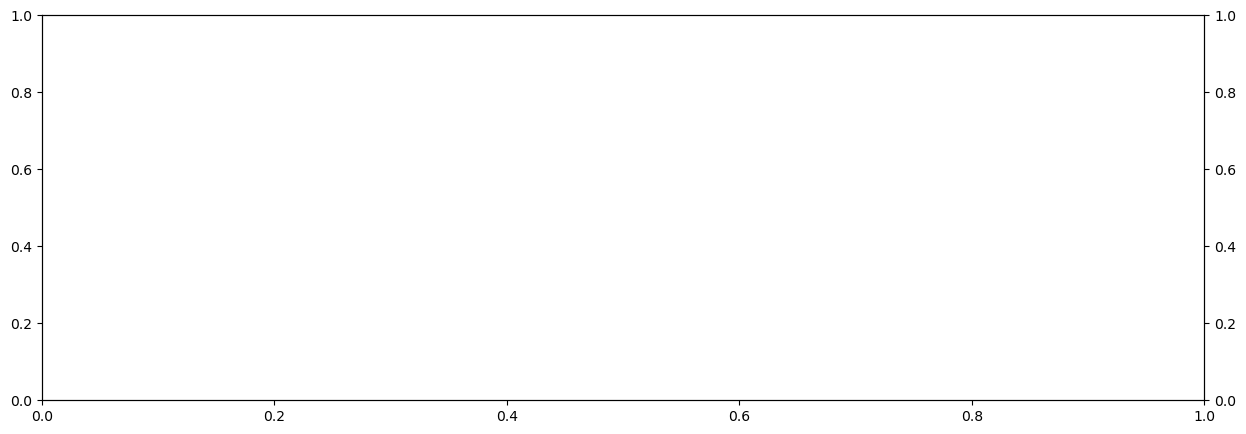

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))

DIFF2REF = 0
ax1 = ax.twinx()

fnames = [
    'situnefb_purenoise.pkl',
    'situnefb_pidmode-1_25cut_nomean.pkl',
    'situnefb_pidmode1_25cut_nomean.pkl',
    'situnefb_pidmode0_25cut_nomean.pkl',
    ]
for i, fname in enumerate(fnames):
    r = load(fname)
    tunex = _np.array(r['tunex'])[:] - sim._ref_tunex*DIFF2REF
    tuney = _np.array(r['tuney'])[:] - sim._ref_tuney*DIFF2REF

    strf = f'{" "+fname:.>40s} => '+\
        f'Tune X STD = {tunex.std():.3e},  '+\
        f'Tune Y STD = {tuney.std():.3e}\n'
    print(strf)

    x = _np.arange(len(tunex))
    ax.plot(x + x[-1]*i, tunex, '-', c='C0')
    ax1.plot(x + x[-1]*i, tuney, '-', c='C1')

ax.yaxis.set_tick_params(labelcolor='C0')
ax1.yaxis.set_tick_params(labelcolor='C1')

fig.tight_layout()
fig.show()